In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)
else:
    print("WARNING: CUDA is not available. Training on CPU.")

Device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
CUDA: 12.8


In [ ]:
DATASET_ROOT = r"D:\MV Project\data"

BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-4

# IMPORTANT:
# For Jupyter/Windows, use 0 first.
NUM_WORKERS = 0

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [3]:
train_tf = transforms.Compose([
    transforms.ToTensor(),

    transforms.RandomHorizontalFlip(),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

val_tf = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [4]:
train_dataset = datasets.ImageFolder(
    os.path.join(DATASET_ROOT, "train"),
    transform=train_tf
)

val_dataset = datasets.ImageFolder(
    os.path.join(DATASET_ROOT, "val"),
    transform=val_tf
)

print("Classes:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Classes: ['destroyed', 'major_damage', 'minor_damage', 'no_damage']
Class mapping: {'destroyed': 0, 'major_damage': 1, 'minor_damage': 2, 'no_damage': 3}
Training samples: 91325
Validation samples: 22183


In [5]:
# Only use pinned memory when CUDA is available
pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("pin_memory:", pin_memory)

Train batches: 2854
Validation batches: 694
pin_memory: True


In [6]:
labels = [
    y for _, y in train_dataset.samples
]

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("Classes:", train_dataset.classes)
print("Class weights:", class_weights)

Classes: ['destroyed', 'major_damage', 'minor_damage', 'no_damage']
Class weights: tensor([4.1762, 2.4914, 2.6747, 0.3350], device='cuda:0')


In [7]:
model = models.mobilenet_v2(
    weights=models.MobileNet_V2_Weights.DEFAULT
)

# Replace ImageNet classifier
# 1000 classes -> 4 classes
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    4
)

model = model.to(device)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=4, bias=True)
)


In [8]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    patience=2
)

print("Optimizer:", optimizer)
print("Initial LR:", LR)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
Initial LR: 0.0001


In [9]:
from tqdm.auto import tqdm

train_loss_hist = []
val_loss_hist = []

train_acc_hist = []
val_acc_hist = []

best_acc = 0.0

for epoch in range(EPOCHS):

    # =====================================================
    # TRAIN
    # =====================================================

    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    train_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS} [TRAIN]",
        leave=True
    )

    for x, y in train_bar:

        x = x.to(
            device,
            non_blocking=pin_memory
        )

        y = y.to(
            device,
            non_blocking=pin_memory
        )

        optimizer.zero_grad()

        out = model(x)

        loss = criterion(out, y)

        loss.backward()

        optimizer.step()

        # Statistics
        train_loss += loss.item() * x.size(0)

        train_correct += (
            out.argmax(1) == y
        ).sum().item()

        train_total += y.size(0)

        current_acc = train_correct / train_total
        current_loss = train_loss / train_total

        # Update progress bar
        train_bar.set_postfix(
            loss=f"{current_loss:.4f}",
            acc=f"{current_acc:.4f}"
        )

    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct / train_total

    train_loss_hist.append(epoch_train_loss)
    train_acc_hist.append(epoch_train_acc)

    # =====================================================
    # VALIDATION
    # =====================================================

    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    all_preds = []
    all_labels = []

    val_bar = tqdm(
        val_loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS} [VAL]",
        leave=True
    )

    with torch.no_grad():

        for x, y in val_bar:

            x = x.to(
                device,
                non_blocking=pin_memory
            )

            y = y.to(
                device,
                non_blocking=pin_memory
            )

            out = model(x)

            loss = criterion(out, y)

            val_loss += loss.item() * x.size(0)

            predictions = out.argmax(1)

            val_correct += (
                predictions == y
            ).sum().item()

            val_total += y.size(0)

            all_preds.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                y.cpu().numpy()
            )

            current_val_acc = val_correct / val_total
            current_val_loss = val_loss / val_total

            val_bar.set_postfix(
                loss=f"{current_val_loss:.4f}",
                acc=f"{current_val_acc:.4f}"
            )

    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total

    val_loss_hist.append(epoch_val_loss)
    val_acc_hist.append(epoch_val_acc)

    # =====================================================
    # SCHEDULER
    # =====================================================

    scheduler.step(epoch_val_acc)

    current_lr = optimizer.param_groups[0]["lr"]

    # =====================================================
    # EPOCH SUMMARY
    # =====================================================

    print(
        f"\nEpoch {epoch + 1}/{EPOCHS} COMPLETE"
    )

    print(
        f"Train Loss : {epoch_train_loss:.4f}"
    )

    print(
        f"Train Acc  : {epoch_train_acc:.4f}"
    )

    print(
        f"Val Loss   : {epoch_val_loss:.4f}"
    )

    print(
        f"Val Acc    : {epoch_val_acc:.4f}"
    )

    print(
        f"Learning Rate: {current_lr:.6f}"
    )

    # =====================================================
    # SAVE BEST MODEL
    # =====================================================

    if epoch_val_acc > best_acc:

        best_acc = epoch_val_acc

        torch.save(
            model.state_dict(),
            "best_model.pth"
        )

        print(
            f"*** NEW BEST MODEL SAVED *** "
            f"Val Acc = {best_acc:.4f}"
        )

    print("-" * 70)


print("\n" + "=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)
print(f"Best Validation Accuracy: {best_acc:.4f}")

c:\Users\shekh\miniconda3\envs\based\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Epoch 1/15 [VAL]: 100%|██████████| 694/694 [03:55<00:00,  2.94it/s, acc=0.7100, loss=0.7536]



Epoch 1/15 COMPLETE
Train Loss : 0.8477
Train Acc  : 0.6760
Val Loss   : 0.7536
Val Acc    : 0.7100
Learning Rate: 0.000100
*** NEW BEST MODEL SAVED *** Val Acc = 0.7100
----------------------------------------------------------------------


Epoch 2/15 [VAL]: 100%|██████████| 694/694 [04:09<00:00,  2.78it/s, acc=0.7552, loss=0.6531]



Epoch 2/15 COMPLETE
Train Loss : 0.6927
Train Acc  : 0.7543
Val Loss   : 0.6531
Val Acc    : 0.7552
Learning Rate: 0.000100
*** NEW BEST MODEL SAVED *** Val Acc = 0.7552
----------------------------------------------------------------------


Epoch 3/15 [VAL]: 100%|██████████| 694/694 [04:08<00:00,  2.80it/s, acc=0.7399, loss=0.6792]


...


Epoch 13/15 COMPLETE
Train Loss : 0.2303
Train Acc  : 0.8958
Val Loss   : 0.7189
Val Acc    : 0.7707
Learning Rate: 0.000001
----------------------------------------------------------------------


Epoch 14/15 [VAL]: 100%|██████████| 694/694 [03:44<00:00,  3.09it/s, acc=0.7775, loss=0.6962]



Epoch 14/15 COMPLETE
Train Loss : 0.2275
Train Acc  : 0.8981
Val Loss   : 0.6962
Val Acc    : 0.7775
Learning Rate: 0.000001
*** NEW BEST MODEL SAVED *** Val Acc = 0.7775
----------------------------------------------------------------------


Epoch 15/15 [VAL]: 100%|██████████| 694/694 [02:36<00:00,  4.44it/s, acc=0.7687, loss=0.7303]



Epoch 15/15 COMPLETE
Train Loss : 0.2249
Train Acc  : 0.8985
Val Loss   : 0.7303
Val Acc    : 0.7687
Learning Rate: 0.000001
----------------------------------------------------------------------

TRAINING COMPLETE
Best Validation Accuracy: 0.7775


In [10]:
model.load_state_dict(
    torch.load(
        "best_model.pth",
        map_location=device
    )
)

model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


Validation evaluation complete.
              precision    recall  f1-score   support

   destroyed     0.8280    0.8121    0.8200      1778
major_damage     0.4471    0.5957    0.5108      2162
minor_damage     0.3850    0.5438    0.4508      2398
   no_damage     0.9323    0.8338    0.8803     15845

    accuracy                         0.7775     22183
   macro avg     0.6481    0.6964    0.6655     22183
weighted avg     0.8175    0.7775    0.7930     22183

Confusion Matrix:
[[ 1444    82    76   176]
 [   64  1288   496   314]
 [   31   593  1304   470]
 [  205   918  1511 13211]]


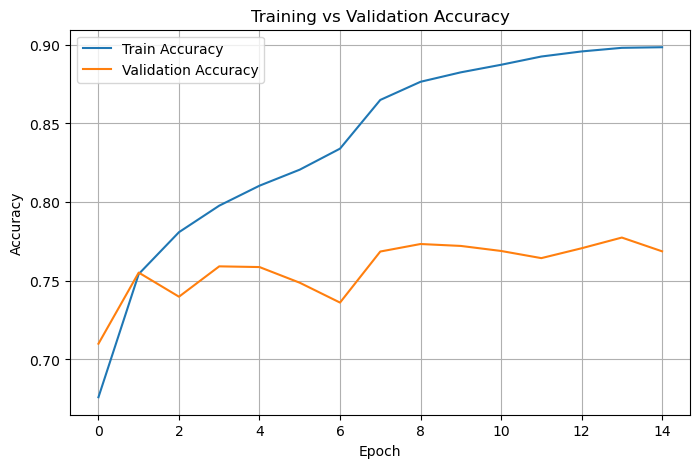

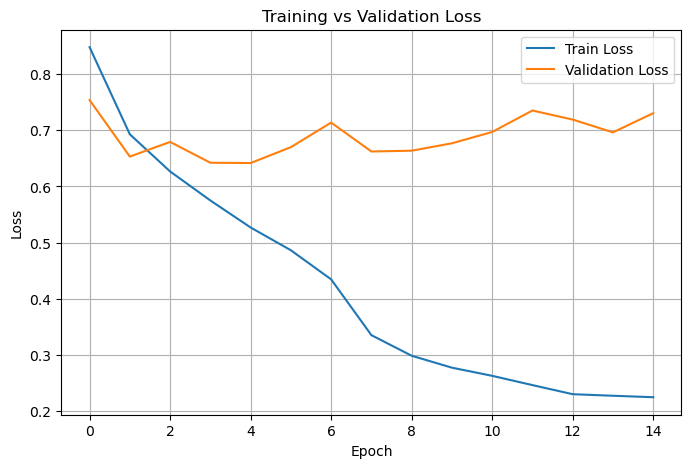

In [11]:
all_preds = []
all_labels = []

with torch.no_grad():

    for x, y in val_loader:

        x = x.to(
            device,
            non_blocking=pin_memory
        )

        y = y.to(
            device,
            non_blocking=pin_memory
        )

        out = model(x)

        predictions = out.argmax(1)

        all_preds.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            y.cpu().numpy()
        )

print("Validation evaluation complete.")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=train_dataset.classes,
        digits=4
    )
)

cm = confusion_matrix(
    all_labels,
    all_preds
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(8, 5))

plt.plot(
    train_acc_hist,
    label="Train Accuracy"
)

plt.plot(
    val_acc_hist,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    train_loss_hist,
    label="Train Loss"
)

plt.plot(
    val_loss_hist,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()